# ResNet vs PlainNet — Ablation Study

ResNet의 핵심 아이디어인 **skip connection(residual)** 의 효과를, 같은 레이어 구성의
**PlainNet**(skip 없음)과 비교해 확인하는 노트북입니다.

- Keras **Functional API** 로 ResNet-18/34/50/101/152 및 Plain-34/50 을 하나의 빌더로 생성
- 논문(He et al., 2015) 명세 반영: Table 1 구성, Option B shortcut, bottleneck 첫 1x1 conv에 stride, He 초기화
- 데이터셋: Oxford-IIIT Pet (224x224, 37 클래스)
- 검증 정확도 / 검증 손실 곡선 비교

> **GPU 런타임에서 실행하세요** (런타임 → 런타임 유형 변경 → GPU).

In [1]:
# Colab 기본 제공: tensorflow, matplotlib. tfds만 보장 위해 설치
!pip install -q tensorflow_datasets

## 1. 모델 정의 (Functional API)

블록 함수에 `use_skip` 인자를 둬서, 같은 코드로 ResNet과 PlainNet을 모두 만든다.

In [3]:
import tensorflow as tf
from tensorflow.keras import Input, Model, layers


def conv_bn(x, filters, kernel_size, strides=1, activation=True, name=None):
    """Conv2D -> BatchNorm -> (ReLU). He 초기화, BN 사용으로 bias 생략."""
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding="same",
                      use_bias=False, kernel_initializer="he_normal",
                      name=None if name is None else name + "_conv")(x)
    x = layers.BatchNormalization(name=None if name is None else name + "_bn")(x)
    if activation:
        x = layers.Activation("relu", name=None if name is None else name + "_relu")(x)
    return x


def basic_block(x, filters, strides=1, use_skip=True, name=None):
    """BasicBlock(18/34): 3x3 -> 3x3. use_skip=False면 PlainNet 블록."""
    in_channels = x.shape[-1]
    y = conv_bn(x, filters, 3, strides=strides, name=None if name is None else name + "_1")
    y = conv_bn(y, filters, 3, strides=1, activation=False, name=None if name is None else name + "_2")
    if not use_skip:
        return layers.Activation("relu", name=None if name is None else name + "_out")(y)
    shortcut = x
    if strides != 1 or in_channels != filters:
        shortcut = conv_bn(x, filters, 1, strides=strides, activation=False,
                           name=None if name is None else name + "_sc")
    y = layers.Add(name=None if name is None else name + "_add")([y, shortcut])
    return layers.Activation("relu", name=None if name is None else name + "_out")(y)


def bottleneck_block(x, filters, strides=1, use_skip=True, name=None):
    """Bottleneck(50/101/152): 1x1 -> 3x3 -> 1x1. 논문 원본대로 stride는 첫 1x1."""
    expansion = 4
    out_channels = filters * expansion
    in_channels = x.shape[-1]
    y = conv_bn(x, filters, 1, strides=strides, name=None if name is None else name + "_1")
    y = conv_bn(y, filters, 3, strides=1, name=None if name is None else name + "_2")
    y = conv_bn(y, out_channels, 1, strides=1, activation=False, name=None if name is None else name + "_3")
    if not use_skip:
        return layers.Activation("relu", name=None if name is None else name + "_out")(y)
    shortcut = x
    if strides != 1 or in_channels != out_channels:
        shortcut = conv_bn(x, out_channels, 1, strides=strides, activation=False,
                           name=None if name is None else name + "_sc")
    y = layers.Add(name=None if name is None else name + "_add")([y, shortcut])
    return layers.Activation("relu", name=None if name is None else name + "_out")(y)


BLOCK_FNS = {"basic": basic_block, "bottleneck": bottleneck_block}


def _build_network(input_shape=(224, 224, 3), num_classes=1000, block_type="basic",
                   num_blocks=(3, 4, 6, 3), filters=(64, 128, 256, 512),
                   use_skip=True, name="resnet"):
    block_fn = BLOCK_FNS[block_type]
    inputs = Input(shape=input_shape)
    x = conv_bn(inputs, 64, 7, strides=2, name="stem")
    x = layers.MaxPooling2D(3, strides=2, padding="same", name="stem_pool")(x)
    for stage_idx, (f, n) in enumerate(zip(filters, num_blocks)):
        for block_idx in range(n):
            strides = 2 if (block_idx == 0 and stage_idx > 0) else 1
            x = block_fn(x, f, strides=strides, use_skip=use_skip,
                         name=f"stage{stage_idx + 1}_block{block_idx + 1}")
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    return Model(inputs, outputs, name=name)


def build_resnet(input_shape=(224, 224, 3), num_classes=1000, block_type="basic",
                 num_blocks=(3, 4, 6, 3), filters=(64, 128, 256, 512), name="resnet"):
    return _build_network(input_shape, num_classes, block_type, num_blocks, filters, True, name)


def build_plainnet(input_shape=(224, 224, 3), num_classes=1000, block_type="basic",
                   num_blocks=(3, 4, 6, 3), filters=(64, 128, 256, 512), name="plainnet"):
    return _build_network(input_shape, num_classes, block_type, num_blocks, filters, False, name)


def resnet34(input_shape=(224,224,3), num_classes=1000):
    return build_resnet(input_shape, num_classes, "basic", (3,4,6,3), name="resnet34")
def resnet50(input_shape=(224,224,3), num_classes=1000):
    return build_resnet(input_shape, num_classes, "bottleneck", (3,4,6,3), name="resnet50")
def plainnet34(input_shape=(224,224,3), num_classes=1000):
    return build_plainnet(input_shape, num_classes, "basic", (3,4,6,3), name="plainnet34")
def plainnet50(input_shape=(224,224,3), num_classes=1000):
    return build_plainnet(input_shape, num_classes, "bottleneck", (3,4,6,3), name="plainnet50")

## 2. 모델 확인

Functional API라 `summary()`에 모든 레이어가 펼쳐져 나온다. 파라미터 수도 비교.

In [4]:
for build, label in [(resnet34, "ResNet-34"), (plainnet34, "Plain-34"),
                     (resnet50, "ResNet-50"), (plainnet50, "Plain-50")]:
    m = build()
    n = int(sum(tf.size(w) for w in m.trainable_weights))
    print(f"{label:10s} trainable params: {n:,}")

# 전체 레이어 구성 펼쳐 보기 (예: ResNet-34)
resnet34().summary()

ResNet-34  trainable params: 21,797,672
Plain-34   trainable params: 21,623,848
ResNet-50  trainable params: 25,557,032
Plain-50   trainable params: 22,780,456


Model: "resnet34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      9,408 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 56, 56,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_1_co… │ (None, 56, 56,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_1_bn  │ (None, 56, 56,    │        256 │ stage1_block1_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_1_re… │ (None, 56, 56,    │          0 │ stage1_block1_1_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_2_co… │ (None, 56, 56,    │     36,864 │ stage1_block1_1_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_2_bn  │ (None, 56, 56,    │        256 │ stage1_block1_2_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 56, 56,    │          0 │ stage1_block1_2_… │
│ (Add)               │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 56, 56,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_1_co… │ (None, 56, 56,    │     36,864 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_1_bn  │ (None, 56, 56,    │        256 │ stage1_block2_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_1_re… │ (None, 56, 56,    │          0 │ stage1_block2_1_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_2_co… │ (None, 56, 56,    │     36,864 │ stage1_block2_1_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_2_bn  │ (None, 56, 56,    │        256 │ stage1_block2_2_

 Total params: 21,814,696 (83.22 MB)

 Trainable params: 21,797,672 (83.15 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. 데이터셋: Oxford-IIIT Pet (224x224, 37 클래스)

In [5]:
import tensorflow_datasets as tfds

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 37
AUTOTUNE = tf.data.AUTOTUNE


def preprocess(image, label, training):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if training:
        image = tf.image.random_flip_left_right(image)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


(ds_train, ds_test), info = tfds.load(
    "oxford_iiit_pet", split=["train", "test"],
    as_supervised=True, with_info=True)

ds_train = (ds_train.map(lambda x, y: preprocess(x, y, True), num_parallel_calls=AUTOTUNE)
            .shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE))
ds_test = (ds_test.map(lambda x, y: preprocess(x, y, False), num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))
print("train/test 준비 완료")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.3Z1JLM_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.3Z1JLM_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
train/test 준비 완료


## 4. 학습 (확인용 적은 epoch)

`DEPTH` 를 34 또는 50 으로 바꿔 비교 대상을 선택.

In [9]:
EPOCHS = 50      # 확인용. 시간 여유 있으면 늘리세요.
DEPTH = 50       # 34 또는 50

res_fn, plain_fn = (resnet34, plainnet34) if DEPTH == 34 else (resnet50, plainnet50)


def train_one(build_fn, name):
    print(f"\n{'='*50}\n{name} 학습\n{'='*50}")
    model = build_fn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model.fit(ds_train, validation_data=ds_test, epochs=EPOCHS, verbose=1)


hist_res = train_one(res_fn, f"ResNet-{DEPTH}")
hist_plain = train_one(plain_fn, f"Plain-{DEPTH}")


ResNet-50 학습
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 105s 488ms/step - accuracy: 0.0465 - loss: 3.7315 - val_accuracy: 0.0338 - val_loss: 3.8772
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 51s 419ms/step - accuracy: 0.0726 - loss: 3.4877 - val_accuracy: 0.0338 - val_loss: 4.8934
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 83s 414ms/step - accuracy: 0.1128 - loss: 3.3085 - val_accuracy: 0.0657 - val_loss: 4.1461
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 50s 406ms/step - accuracy: 0.1478 - loss: 3.1668 - val_accuracy: 0.1115 - val_loss: 3.4812
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 83s 425ms/step - accuracy: 0.1658 - loss: 3.0296 - val_accuracy: 0.0796 - val_loss: 4.2884
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 494ms/step - accuracy: 0.1867 - loss: 2.9210 - val_accuracy: 0.0837 - val_loss: 3.9167
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 73s 426ms/step - accuracy: 0.2128 - loss: 2.8001 - val_accuracy: 0.1112 - val_loss: 3.6355
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 496ms/step - accuracy: 0

## 5. 결과 비교 시각화

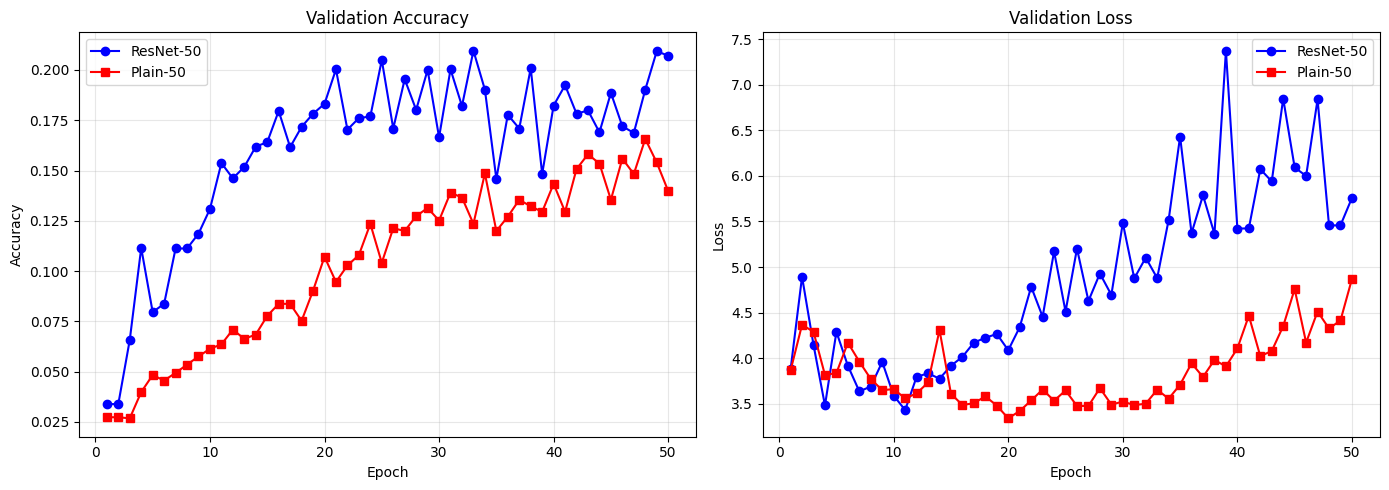

ResNet-50 최종 val_acc: 0.2071
Plain-50  최종 val_acc: 0.1398


In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(hist_res.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, hist_res.history["val_accuracy"], "b-o", label=f"ResNet-{DEPTH}")
axes[0].plot(epochs, hist_plain.history["val_accuracy"], "r-s", label=f"Plain-{DEPTH}")
axes[0].set_title("Validation Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, hist_res.history["val_loss"], "b-o", label=f"ResNet-{DEPTH}")
axes[1].plot(epochs, hist_plain.history["val_loss"], "r-s", label=f"Plain-{DEPTH}")
axes[1].set_title("Validation Loss"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig("ablation_resnet_vs_plain.png", dpi=120); plt.show()

print(f"ResNet-{DEPTH} 최종 val_acc: {hist_res.history['val_accuracy'][-1]:.4f}")
print(f"Plain-{DEPTH}  최종 val_acc: {hist_plain.history['val_accuracy'][-1]:.4f}")

회고

그러면 accu는 높이면서 loss를 줄이려면 어케해야할까?

1. transfer learning
image net이 잘되어잇는 모델을 가져와 fine tuning하는 방식

2. 데이터 늘리기/ 증강
3. Early stopping
4. 규제(regularization) 추가